# Lab 7.04 - Time series analysis

In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import pandas as pd                                 # Dataframe

import scipy.stats as stats                         # Statistical tests
from sklearn.linear_model import LinearRegression   # Linear regression model

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz

### Exercise 4 - Airline ticket data

Consider the airline ticket data in the file airline ticket data.csv  

- Create a time series chart of the data. Based on what you see, which of the exponential smoothing models do you think should be used for forecasting? Why?
- Create and train the model. Predict the values for the next 12 months.
- Create a plot with the airline ticket data and the predicted values for the next 12 months.

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/airline%20ticket%20data.csv', delimiter = ";", parse_dates=['Month']).set_index(['Month'])
data.head()

C:\Users\Jelle\AppData\Local\Temp\ipykernel_19340\4084518144.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/airline%20ticket%20data.csv', delimiter = ";", parse_dates=['Month']).set_index(['Month'])


,Tickets
Month,
2018-01-01,605
2018-02-01,647
2018-03-01,636
2018-04-01,612
2018-05-01,714


<Axes: xlabel='Month'>

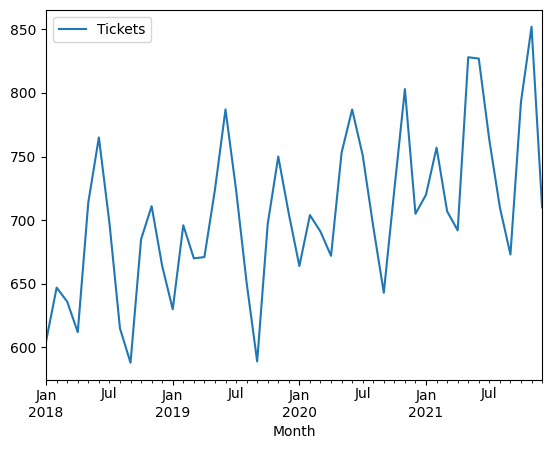

In [3]:
data.plot(y='Tickets')

Er is een duidelijk zichtbare stijgende trend en er is zeker ook een seasonal component aanwezig. Je ziet dat de tickets voor juli en november steeds wat hoger liggen dan de rest van de maanden. Hier rekening mee houdend, lijkt triple exponential smoothing het beste model om toe te passen.

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
test_data = data['2021-01-01':]
training_data = data[:'2020-12-01']

data_tes = ExponentialSmoothing(training_data, trend='add', seasonal='add', seasonal_periods=12, freq='MS').fit()
tes_fcast = data_tes.forecast(12)
print(tes_fcast)

2021-01-01    687.333268
2021-02-01    736.661895
2021-03-01    719.991287
2021-04-01    705.995386
2021-05-01    784.661889
2021-06-01    833.999080
2021-07-01    778.670899
2021-08-01    708.002142
2021-09-01    661.002222
2021-10-01    756.336343
2021-11-01    808.994343
2021-12-01    745.665223
Freq: MS, dtype: float64


<Axes: xlabel='Month'>

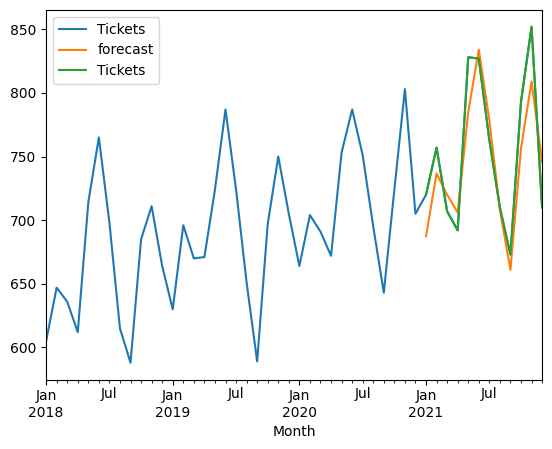

In [13]:
data.plot(y='Tickets')
tes_fcast.plot(legend=True, label='forecast')
test_data['Tickets'].plot(legend=True, label='Tickets')

## Source
Business Analytics Data Analysis & Decision Making 